# Sales Lead Conversion & Segmentation Intelligence

**Author:** Nitin Prasad

**Notebook:** 03_Lead_Segmentation_Clustering

### Purpose

Identify meaningful lead segments using behavioral and business characteristics, evaluate the clustering results, profile the segments, and save the final clustering pipeline for Streamlit deployment.

**Input:** `cleaned_leads.csv`

**Output:** K-Means model, cluster profiles & evaluation metrics

**Model:** K-Means Clustering


## 1. Import Libraries and Setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

print("Clustering notebook setup completed.")

Clustering notebook setup completed.


## 2. Load the Clean Dataset

In [2]:
file_path = Path("../Dataset/cleaned_leads.csv")

df = pd.read_csv(file_path)

print("Cleaned dataset loaded successfully.")

Cleaned dataset loaded successfully.


### 2.1 Basic Dataset Check

Verify the dimensions of the dataset and inspect the available columns before selecting the variables for clustering.

In [3]:
print(f"Dataset shape: {df.shape}")

display(df.head())

Dataset shape: (19269, 28)


,Lead_ID,Lead_Date,Industry,State,Employee_Count,Lead_Source,Campaign_Type,Sales_Rep_Interactions,Previous_Interactions,Days_Since_Last_Interaction,Website_Visits,Pages_Viewed,Email_Opens,Email_Clicks,Content_Downloads,Demo_Attended,Estimated_Budget,Estimated_Deal_Value,Decision_Maker,Contact_Requests,Product_Page_Visits,Trial_Started,Converted,Company_Size,Total_Interactions,Digital_Engagement_Score,Budget_per_Employee,Deal_to_Budget_Ratio
0,L000001,2024-03-27,Financial Services,Rajasthan,260.00,Website,Free Trial,4.00,6.00,26.00,7.00,10.00,13.00,3.00,1.00,No,"161,000.00","175,000.00",Yes,0.00,NaN,No,0,Large,10.00,8.00,619.23,1.09
1,L000002,2026-01-23,Logistics,West Bengal,10.00,Google Ads,Free Trial,1.00,3.00,33.00,18.00,28.00,10.00,3.00,1.00,No,"51,000.00","35,000.00",No,0.00,8.00,No,0,Small,4.00,13.60,"5,100.00",0.69
2,L000003,2025-09-28,Financial Services,West Bengal,14.00,LinkedIn,Content Marketing,2.00,2.00,32.00,13.00,21.00,9.00,1.00,2.00,Yes,"54,000.00","65,000.00",No,1.00,7.00,No,0,Small,4.00,10.50,"3,857.14",1.20
3,L000005,2025-02-25,Healthcare,Kerala,6.00,Website,Enterprise Outreach,4.00,12.00,NaN,8.00,20.00,8.00,3.00,2.00,No,"47,000.00","55,000.00",No,0.00,NaN,No,0,Small,16.00,10.75,"7,833.33",1.17
4,L000006,2026-04-15,Professional Services,Rajasthan,73.00,LinkedIn,Product Demo,5.00,6.00,20.00,38.00,78.00,8.00,NaN,6.00,Yes,"73,000.00","115,000.00",Yes,1.00,24.00,Yes,1,Medium,11.00,38.75,"1,000.00",1.58


In [4]:
print(df.columns.tolist())

['Lead_ID', 'Lead_Date', 'Industry', 'State', 'Employee_Count', 'Lead_Source', 'Campaign_Type', 'Sales_Rep_Interactions', 'Previous_Interactions', 'Days_Since_Last_Interaction', 'Website_Visits', 'Pages_Viewed', 'Email_Opens', 'Email_Clicks', 'Content_Downloads', 'Demo_Attended', 'Estimated_Budget', 'Estimated_Deal_Value', 'Decision_Maker', 'Contact_Requests', 'Product_Page_Visits', 'Trial_Started', 'Converted', 'Company_Size', 'Total_Interactions', 'Digital_Engagement_Score', 'Budget_per_Employee', 'Deal_to_Budget_Ratio']


## 3. Select Clustering Features

Select numerical features representing lead engagement, interaction history, recency, commercial potential, and company size.

Highly redundant component variables and the supervised target `Converted` are excluded from the clustering inputs.

The selected features are:

- `Digital_Engagement_Score`
- `Total_Interactions`
- `Days_Since_Last_Interaction`
- `Estimated_Budget`
- `Employee_Count`
- `Deal_to_Budget_Ratio`

In [5]:
clustering_features = [
    "Digital_Engagement_Score",
    "Total_Interactions",
    "Days_Since_Last_Interaction",
    "Estimated_Budget",
    "Employee_Count",
    "Deal_to_Budget_Ratio"
]

X_cluster = df[clustering_features].copy()

print("Clustering features:")
print(clustering_features)

print("\nClustering dataset shape:", X_cluster.shape)

Clustering features:
['Digital_Engagement_Score', 'Total_Interactions', 'Days_Since_Last_Interaction', 'Estimated_Budget', 'Employee_Count', 'Deal_to_Budget_Ratio']

Clustering dataset shape: (19269, 6)


In [6]:
display(X_cluster.head())

,Digital_Engagement_Score,Total_Interactions,Days_Since_Last_Interaction,Estimated_Budget,Employee_Count,Deal_to_Budget_Ratio
0,8.00,10.00,26.00,"161,000.00",260.00,1.09
1,13.60,4.00,33.00,"51,000.00",10.00,0.69
2,10.50,4.00,32.00,"54,000.00",14.00,1.20
3,10.75,16.00,NaN,"47,000.00",6.00,1.17
4,38.75,11.00,20.00,"73,000.00",73.00,1.58


## 4. Build the Clustering Preprocessing Pipeline

Prepare the selected clustering features for K-Means clustering.

- Missing numerical values will be replaced using median imputation.
- Features will be standardized so that all variables contribute on a comparable scale to the distance calculations used by K-Means.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

clustering_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Clustering preprocessing pipeline created.")

Clustering preprocessing pipeline created.


In [8]:
X_cluster_scaled = clustering_preprocessor.fit_transform(X_cluster)

print("Original shape:", X_cluster.shape)
print("Transformed shape:", X_cluster_scaled.shape)

Original shape: (19269, 6)
Transformed shape: (19269, 6)


In [9]:
print("Missing values after preprocessing:",
      np.isnan(X_cluster_scaled).sum())

print(
    "Mean of transformed features:",
    np.round(X_cluster_scaled.mean(axis=0), 3)
)

print(
    "Std of transformed features:",
    np.round(X_cluster_scaled.std(axis=0), 3)
)

Missing values after preprocessing: 0
Mean of transformed features: [ 0. -0.  0. -0.  0.  0.]
Std of transformed features: [1. 1. 1. 1. 1. 1.]


## 5. Determine the Optimal Number of Clusters

Evaluate different numbers of clusters using the Elbow Method and Silhouette Score.

Candidate values of K from 2 through 6 will be tested.

- Inertia measures within-cluster compactness.
- Silhouette Score measures how well-separated the resulting clusters are.

The final number of clusters will be selected using these metrics along with the business interpretability of the resulting segments.

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [11]:
k_values = range(2, 7)

inertia_scores = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_cluster_scaled)
    
    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_cluster_scaled, cluster_labels)
    )

In [12]:
cluster_evaluation = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_scores,
    "Silhouette_Score": silhouette_scores
})

display(cluster_evaluation.round(4))

,K,Inertia,Silhouette_Score
0,2,"95,975.02",0.32
1,3,"80,470.25",0.29
2,4,"66,749.56",0.31
3,5,"56,944.13",0.25
4,6,"50,826.43",0.25


### 5.1 Elbow Method

Visualize the change in within-cluster inertia as the number of clusters increases.

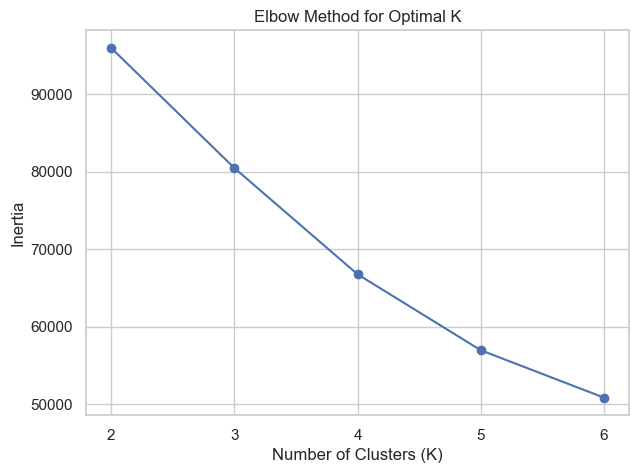

In [13]:
plt.figure(figsize=(7, 5))

plt.plot(
    cluster_evaluation["K"],
    cluster_evaluation["Inertia"],
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.show()

### 5.2 Silhouette Score

Visualize the silhouette score for each candidate number of clusters.

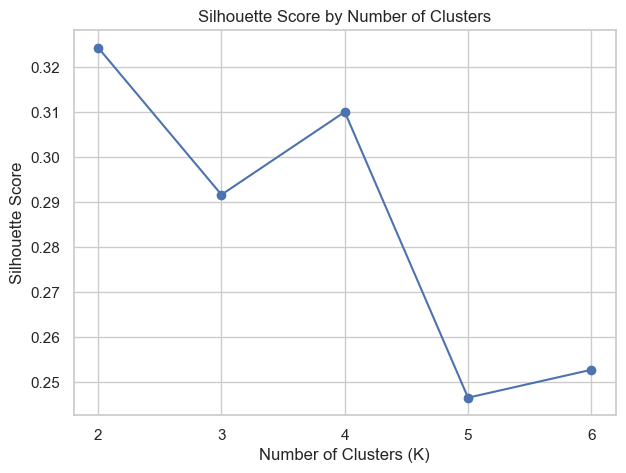

In [14]:
plt.figure(figsize=(7, 5))

plt.plot(
    cluster_evaluation["K"],
    cluster_evaluation["Silhouette_Score"],
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.show()

## 6. Profile Candidate Cluster Solutions

Compare the candidate K values using cluster sizes and average values of the clustering features.

The objective is to determine whether the statistically suitable solutions produce meaningful and distinguishable lead segments.

In [15]:
candidate_ks = [2, 3, 4]

candidate_profiles = {}

for k in candidate_ks:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_cluster_scaled)
    
    temp = X_cluster.copy()
    temp["Cluster"] = labels
    
    profile = temp.groupby("Cluster").agg({
        "Digital_Engagement_Score": "mean",
        "Total_Interactions": "mean",
        "Days_Since_Last_Interaction": "mean",
        "Estimated_Budget": "mean",
        "Employee_Count": "mean",
        "Deal_to_Budget_Ratio": "mean"
    }).round(2)
    
    profile["Lead_Count"] = temp["Cluster"].value_counts().sort_index()
    profile["Lead_Percentage"] = (
        profile["Lead_Count"] / len(temp) * 100
    ).round(2)
    
    candidate_profiles[k] = profile

In [16]:
for k, profile in candidate_profiles.items():
    print(f"\n===== K = {k} =====")
    display(profile)


===== K = 2 =====


,Digital_Engagement_Score,Total_Interactions,Days_Since_Last_Interaction,Estimated_Budget,Employee_Count,Deal_to_Budget_Ratio,Lead_Count,Lead_Percentage
Cluster,,,,,,,,
0,30.30,17.39,20.28,"114,512.23",149.61,1.10,5119,26.57
1,12.53,8.00,36.10,"69,514.11",54.51,1.10,14150,73.43



===== K = 3 =====


,Digital_Engagement_Score,Total_Interactions,Days_Since_Last_Interaction,Estimated_Budget,Employee_Count,Deal_to_Budget_Ratio,Lead_Count,Lead_Percentage
Cluster,,,,,,,,
0,12.03,7.73,36.52,"70,819.61",57.34,1.10,13493,70.02
1,20.86,11.95,32.48,"355,790.61",678.59,1.10,525,2.72
2,30.29,17.43,19.99,"80,095.28",77.08,1.10,5251,27.25



===== K = 4 =====


,Digital_Engagement_Score,Total_Interactions,Days_Since_Last_Interaction,Estimated_Budget,Employee_Count,Deal_to_Budget_Ratio,Lead_Count,Lead_Percentage
Cluster,,,,,,,,
0,30.56,17.56,19.81,"80,126.63",77.22,1.10,5101,26.47
1,12.09,7.77,33.39,"70,894.57",57.41,1.10,13525,70.19
2,20.82,11.97,27.01,"356,095.05",678.81,1.10,518,2.69
3,17.25,9.59,366.37,"86,380.53",100.58,1.09,125,0.65


In [17]:
for k in candidate_ks:
    print(f"\nK = {k}")
    print(
        df.assign(
            Cluster=KMeans(
                n_clusters=k,
                random_state=RANDOM_STATE,
                n_init=10
            ).fit_predict(X_cluster_scaled)
        )["Cluster"].value_counts().sort_index()
    )


K = 2
Cluster
0     5119
1    14150
Name: count, dtype: int64

K = 3
Cluster
0    13493
1      525
2     5251
Name: count, dtype: int64

K = 4
Cluster
0     5101
1    13525
2      518
3      125
Name: count, dtype: int64


## 7. Final K-Means Clustering

Train the final K-Means model using the selected number of clusters.

Based on the Elbow Method, Silhouette Score, cluster sizes, and business interpretability, two clusters were selected.

In [18]:
final_k = 2

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=RANDOM_STATE,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_cluster_scaled)

print("Final K-Means model trained.")

Final K-Means model trained.


In [19]:
df["Cluster"] = cluster_labels

print(df["Cluster"].value_counts().sort_index())

Cluster
0     5119
1    14150
Name: count, dtype: int64


## 8. Final Cluster Profiling

Profile the final K-Means clusters using behavioral, commercial, company, and conversion metrics.

The `Converted` variable is included only for post-clustering analysis to understand the business characteristics and observed conversion behavior of each segment.

In [20]:
cluster_profile = (
    df.groupby("Cluster")
    .agg(
        Lead_Count=("Lead_ID", "count"),
        Digital_Engagement=("Digital_Engagement_Score", "mean"),
        Total_Interactions=("Total_Interactions", "mean"),
        Days_Since_Last_Interaction=("Days_Since_Last_Interaction", "mean"),
        Estimated_Budget=("Estimated_Budget", "mean"),
        Estimated_Deal_Value=("Estimated_Deal_Value", "mean"),
        Employee_Count=("Employee_Count", "mean"),
        Deal_to_Budget_Ratio=("Deal_to_Budget_Ratio", "mean"),
        Conversion_Rate=("Converted", "mean")
    )
)

cluster_profile["Lead_Percentage"] = (
    cluster_profile["Lead_Count"] / len(df) * 100
)

cluster_profile["Conversion_Rate"] = (
    cluster_profile["Conversion_Rate"] * 100
)

cluster_profile = cluster_profile.round(2)

display(cluster_profile)

,Lead_Count,Digital_Engagement,Total_Interactions,Days_Since_Last_Interaction,Estimated_Budget,Estimated_Deal_Value,Employee_Count,Deal_to_Budget_Ratio,Conversion_Rate,Lead_Percentage
Cluster,,,,,,,,,,
0,5119,30.30,17.39,20.28,"114,512.23","125,921.54",149.61,1.10,68.12,26.57
1,14150,12.53,8.00,36.10,"69,514.11","76,826.48",54.51,1.10,28.81,73.43


## 9. Assign Business-Friendly Segment Names

Assign descriptive business labels to the final clusters based on their observed behavioral and commercial profiles.

The labels are assigned after clustering and do not influence the K-Means model.

In [21]:
segment_mapping = {
    0: "High-Intent / Highly Engaged",
    1: "Low-Engagement / Nurture"
}

df["Lead_Segment"] = df["Cluster"].map(segment_mapping)

display(
    df[["Cluster", "Lead_Segment"]].drop_duplicates().sort_values("Cluster")
)

,Cluster,Lead_Segment
4,0,High-Intent / Highly Engaged
0,1,Low-Engagement / Nurture


In [22]:
segment_distribution = (
    df["Lead_Segment"]
    .value_counts()
    .to_frame("Lead_Count")
)

segment_distribution["Lead_Percentage"] = (
    segment_distribution["Lead_Count"] / len(df) * 100
).round(2)

display(segment_distribution)

,Lead_Count,Lead_Percentage
Lead_Segment,,
Low-Engagement / Nurture,14150,73.43
High-Intent / Highly Engaged,5119,26.57


## 10. Visualize Cluster Profiles

Visualize the standardized cluster centers for the final K-Means solution.

The visualization compares the relative characteristics of the identified lead segments across engagement, interaction, recency, commercial potential, and company size.

In [23]:
cluster_centers = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=clustering_features
)

cluster_centers["Lead_Segment"] = [
    segment_mapping[0],
    segment_mapping[1]
]

cluster_centers.set_index("Lead_Segment", inplace=True)

display(cluster_centers.round(2))

,Digital_Engagement_Score,Total_Interactions,Days_Since_Last_Interaction,Estimated_Budget,Employee_Count,Deal_to_Budget_Ratio
Lead_Segment,,,,,,
High-Intent / Highly Engaged,1.24,0.87,-0.35,0.46,0.45,0.02
Low-Engagement / Nurture,-0.45,-0.31,0.13,-0.17,-0.16,-0.01


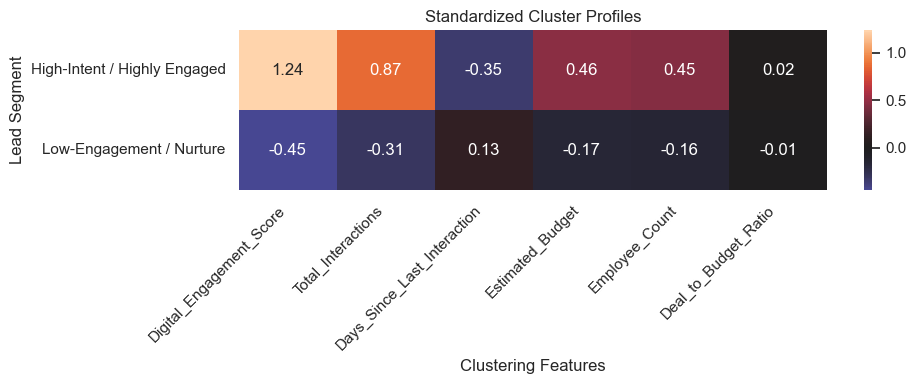

In [25]:
plt.figure(figsize=(10, 4))

sns.heatmap(
    cluster_centers,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Standardized Cluster Profiles")
plt.xlabel("Clustering Features")
plt.ylabel("Lead Segment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 11. PCA Visualization

Reduce the six standardized clustering features to two principal components for visualization.

PCA is used only to visualize the final K-Means clusters in two dimensions. It does not replace the original features used to train the clustering model.

In [26]:
from sklearn.decomposition import PCA

In [27]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_cluster_scaled)

print(
    "Variance explained by PC1:",
    round(pca.explained_variance_ratio_[0] * 100, 2),
    "%"
)

print(
    "Variance explained by PC2:",
    round(pca.explained_variance_ratio_[1] * 100, 2),
    "%"
)

print(
    "Total variance explained:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

Variance explained by PC1: 30.15 %
Variance explained by PC2: 24.46 %
Total variance explained: 54.61 %


In [28]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": df["Cluster"],
    "Lead_Segment": df["Lead_Segment"]
})

display(pca_df.head())

,PC1,PC2,Cluster,Lead_Segment
0,1.21,-1.25,1,Low-Engagement / Nurture
1,-0.94,-0.44,1,Low-Engagement / Nurture
2,-0.98,-0.58,1,Low-Engagement / Nurture
3,-0.60,0.42,1,Low-Engagement / Nurture
4,0.70,1.41,0,High-Intent / Highly Engaged


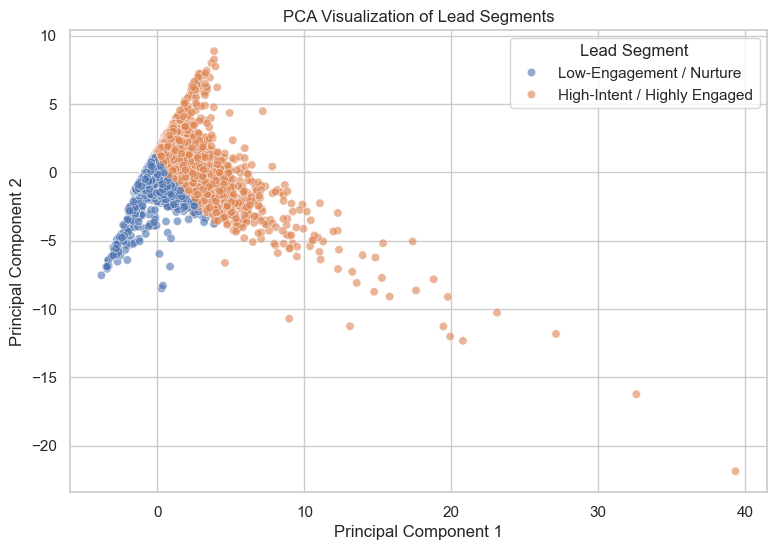

In [29]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Lead_Segment",
    alpha=0.6
)

plt.title("PCA Visualization of Lead Segments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Lead Segment")
plt.show()

In [30]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=clustering_features,
    columns=["PC1", "PC2"]
)

display(pca_loadings.round(3))

,PC1,PC2
Digital_Engagement_Score,0.34,0.56
Total_Interactions,0.28,0.57
Days_Since_Last_Interaction,-0.15,-0.38
Estimated_Budget,0.62,-0.33
Employee_Count,0.62,-0.33
Deal_to_Budget_Ratio,0.01,0.02


## 12. Build Final Clustering Pipeline

Create a single pipeline containing the preprocessing steps and the final K-Means model.

The saved pipeline will allow new leads to be assigned to the same clustering structure without manually repeating preprocessing steps.

In [31]:
from sklearn.pipeline import Pipeline

clustering_pipeline = Pipeline([
    ("preprocessor", clustering_preprocessor),
    ("kmeans", kmeans_final)
])

print("Final clustering pipeline created.")

Final clustering pipeline created.


In [32]:
clustering_pipeline.fit(X_cluster)

,steps,"[('preprocessor', ...), ('kmeans', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None


In [33]:
pipeline_clusters = clustering_pipeline.predict(X_cluster)

print("Number of predicted clusters:", np.unique(pipeline_clusters))
print("Cluster counts:")
print(pd.Series(pipeline_clusters).value_counts().sort_index())

Number of predicted clusters: [0 1]
Cluster counts:
0     5119
1    14150
Name: count, dtype: int64


### 12.1 Save Clustering Pipeline

In [35]:
import joblib

clustering_model_path = Path("../Models/clustering_pipeline.joblib")

clustering_model_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(
    clustering_pipeline,
    clustering_model_path
)

print(f"Clustering pipeline saved to: {clustering_model_path}")

Clustering pipeline saved to: ..\Models\clustering_pipeline.joblib


### 12.2 Save Segment Mapping

In [36]:
segment_mapping_path = Path("../Models/segment_mapping.json")

with open(segment_mapping_path, "w") as f:
    json.dump(segment_mapping, f, indent=4)

print(f"Segment mapping saved to: {segment_mapping_path}")

Segment mapping saved to: ..\Models\segment_mapping.json


## 13. Validate Clustering Pipeline

Test the final clustering pipeline using an existing lead record.

The pipeline should automatically perform preprocessing, assign the lead to one of the trained clusters, and map the cluster number to its business-friendly segment name.

In [37]:
sample_lead = X_cluster.iloc[[0]].copy()

predicted_cluster = clustering_pipeline.predict(sample_lead)[0]

predicted_segment = segment_mapping[predicted_cluster]

print("Predicted Cluster:", predicted_cluster)
print("Predicted Segment:", predicted_segment)

Predicted Cluster: 1
Predicted Segment: Low-Engagement / Nurture


In [38]:
display(sample_lead)

,Digital_Engagement_Score,Total_Interactions,Days_Since_Last_Interaction,Estimated_Budget,Employee_Count,Deal_to_Budget_Ratio
0,8.00,10.00,26.00,"161,000.00",260.00,1.09


In [39]:
all_predictions = clustering_pipeline.predict(X_cluster)

print("Total predictions:", len(all_predictions))
print("Unique clusters:", np.unique(all_predictions))
print("Missing predictions:", pd.Series(all_predictions).isna().sum())

Total predictions: 19269
Unique clusters: [0 1]
Missing predictions: 0


In [40]:
pd.Series(all_predictions).value_counts().sort_index()

0     5119
1    14150
Name: count, dtype: int64

## 14. Save Cluster Profile

In [41]:
cluster_profile_path = Path("../Models/cluster_profile.csv")

cluster_profile.to_csv(
    cluster_profile_path,
    index=True
)

print(f"Cluster profile saved to: {cluster_profile_path}")

Cluster profile saved to: ..\Models\cluster_profile.csv
